In [87]:
import pandas as pd
import numpy as np

In [88]:
df = pd.read_csv("attention_detection_dataset_v1.csv")
df.head()

,no_of_face,face_x,face_y,face_w,face_h,face_con,no_of_hand,pose,pose_x,pose_y,phone,phone_x,phone_y,phone_w,phone_h,phone_con,label
0,1,256.643658,144.163663,169.071331,169.066601,88.813317,0,down,-11.569698,-1.612015,0,0,0,0,0,0.00000,1
1,1,252.967014,137.871659,163.131542,163.126974,86.704057,0,down,-15.000000,10.000000,0,0,0,0,0,0.00000,1
2,1,254.416771,134.427950,155.147362,155.145836,88.408792,0,down,-12.705953,0.082978,0,0,0,0,0,0.00000,1
3,2,256.315517,246.199763,141.227055,141.227217,89.279491,2,right,32.585681,36.572800,1,117,137,276,421,0.86614,1
4,1,293.000126,285.859563,197.011509,196.998653,80.872309,2,forward,-4.013085,-9.905692,0,0,0,0,0,0.00000,1


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   no_of_face  4000 non-null   int64  
 1   face_x      4000 non-null   float64
 2   face_y      4000 non-null   float64
 3   face_w      4000 non-null   float64
 4   face_h      4000 non-null   float64
 5   face_con    4000 non-null   float64
 6   no_of_hand  4000 non-null   int64  
 7   pose        4000 non-null   object 
 8   pose_x      4000 non-null   float64
 9   pose_y      4000 non-null   float64
 10  phone       4000 non-null   int64  
 11  phone_x     4000 non-null   int64  
 12  phone_y     4000 non-null   int64  
 13  phone_w     4000 non-null   int64  
 14  phone_h     4000 non-null   int64  
 15  phone_con   4000 non-null   float64
 16  label       4000 non-null   int64  
dtypes: float64(8), int64(8), object(1)
memory usage: 531.4+ KB


In [90]:
df.isnull().sum()

,0
no_of_face,0
face_x,0
face_y,0
face_w,0
face_h,0
face_con,0
no_of_hand,0
pose,0
pose_x,0
pose_y,0


In [91]:
df['label'].value_counts()

,count
label,
0,2314
1,1686


In [92]:
# Step 2.1: Encode 'pose'
df = pd.get_dummies(df, columns=['pose'])

# Step 2.2: Separate features and label
X = df.drop('label', axis=1)
y = df['label']

# Step 2.3: Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 2.4: Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check shape
print(X_train.shape, X_test.shape)

(3200, 19) (800, 19)


In [93]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [94]:
y_pred = model.predict(X_test)

In [95]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.94625

Confusion Matrix:
 [[439   3]
 [ 40 318]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95       442
           1       0.99      0.89      0.94       358

    accuracy                           0.95       800
   macro avg       0.95      0.94      0.94       800
weighted avg       0.95      0.95      0.95       800



In [96]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [97]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.99625

Confusion Matrix:
 [[441   1]
 [  2 356]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       442
           1       1.00      0.99      1.00       358

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



In [98]:
!pip install xgboost

In [99]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:26:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [100]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Accuracy: 0.9975

Confusion Matrix:
 [[441   1]
 [  1 357]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       442
           1       1.00      1.00      1.00       358

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



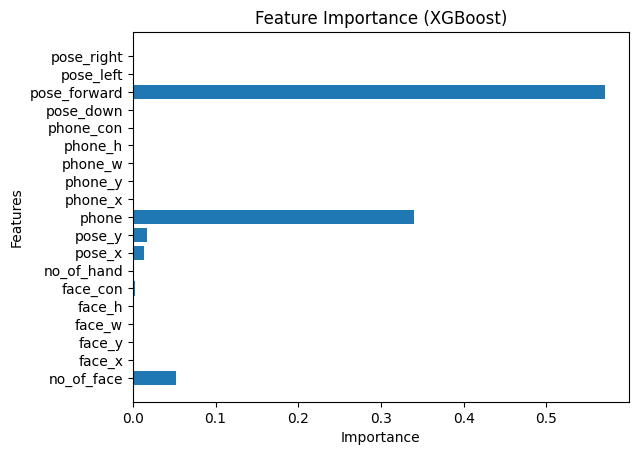

In [101]:
import matplotlib.pyplot as plt

importances = xgb_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance (XGBoost)")
plt.show()

In [102]:
import joblib

joblib.dump(xgb_model, "attention_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [103]:
def predict_attention(input_data):
    input_data = scaler.transform([input_data])
    prediction = xgb_model.predict(input_data)

    if prediction[0] == 0:
        return "Attentive"
    else:
        return "Inattentive"

In [104]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

xgb_cv = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

scores = cross_val_score(xgb_cv, X, y, cv=5, scoring='accuracy')
print("CV Accuracy scores:", scores)
print("Mean CV Accuracy:", scores.mean())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:26:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:26:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:26:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:26:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

CV Accuracy scores: [0.96125 0.97875 0.99375 0.99375 0.98375]
Mean CV Accuracy: 0.98225


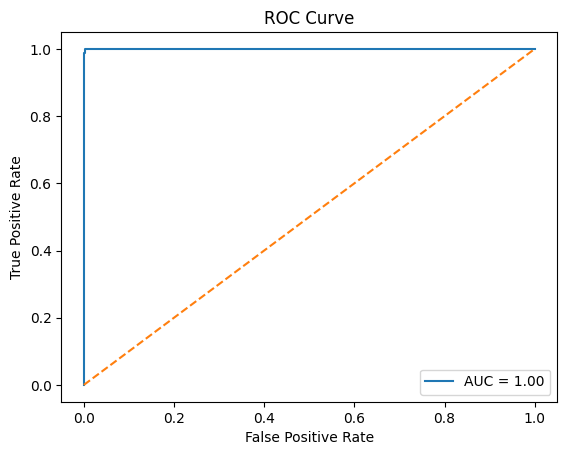

In [105]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [106]:
import pandas as pd

importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(8).index

X_top = X[top_features]

from sklearn.model_selection import train_test_split
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_top, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler2 = StandardScaler()
X_train2 = scaler2.fit_transform(X_train2)
X_test2 = scaler2.transform(X_test2)

xgb_small = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_small.fit(X_train2, y_train2)

from sklearn.metrics import accuracy_score
print("Accuracy with top features:", accuracy_score(y_test2, xgb_small.predict(X_test2)))

Accuracy with top features: 0.9975


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:26:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [107]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.946, 0.996, 0.9975]
})

results

,Model,Accuracy
0,Logistic Regression,0.9460
1,Random Forest,0.9960
2,XGBoost,0.9975


In [108]:
import joblib

joblib.dump(xgb_model, "attention_model.pkl")
joblib.dump(scaler, "scaler.pkl")

# Load example
model_loaded = joblib.load("attention_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")

In [109]:
sample = X.iloc[0].values
sample_scaled = scaler.transform([sample])

pred = xgb_model.predict(sample_scaled)

print("Prediction:", "Attentive" if pred[0]==0 else "Inattentive")

Prediction: Inattentive


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [110]:
import numpy as np

# Head stability (lower movement = better)
df['head_stability'] = 1 / (1 + abs(df['pose_x']) + abs(df['pose_y']))

# Focus direction (forward = 1, others less)
df['focus_direction'] = df['pose_forward'] * 1.0

# Phone factor (no phone = 1, phone = 0)
df['phone_factor'] = 1 - df['phone']

# FINAL ATTENTION ALGORITHM
df['attention_score_algo'] = (
    0.4 * df['focus_direction'] +
    0.3 * df['phone_factor'] +
    0.3 * df['head_stability']
)

In [111]:
import numpy as np

# Head stability (lower movement = better)
df['head_stability'] = 1 / (1 + abs(df['pose_x']) + abs(df['pose_y']))

# Focus direction (forward = 1, others less)
df['focus_direction'] = df['pose_forward'] * 1.0

# Phone factor (no phone = 1, phone = 0)
df['phone_factor'] = 1 - df['phone']

# FINAL ATTENTION ALGORITHM
df['attention_score_algo'] = (
    0.4 * df['focus_direction'] +
    0.3 * df['phone_factor'] +
    0.3 * df['head_stability']
)

In [112]:
df['algo_prediction'] = (df['attention_score_algo'] <= 0.55).astype(int)

In [113]:
from sklearn.metrics import accuracy_score

print("Algorithm Accuracy:", accuracy_score(df['label'], df['algo_prediction']))

Algorithm Accuracy: 0.95025


In [114]:
print("Algorithm Accuracy:", accuracy_score(df['label'], df['algo_prediction']))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

Algorithm Accuracy: 0.95025
XGBoost Accuracy: 0.9975


In [115]:
import os
print(os.listdir())

['.config', 'attention_model.py', 'scaler.pkl', 'feature_columns.pkl', 'attention_detection_dataset_v1.csv', 'attention_model.pkl', '__pycache__', 'sample_data']


In [116]:
X = df.drop('label', axis=1)
y = df['label']

print("Shape:", X.shape)
print("Columns:", list(X.columns))

import joblib
feature_columns = X.columns
joblib.dump(feature_columns, "feature_columns.pkl")

Shape: (4000, 24)
Columns: ['no_of_face', 'face_x', 'face_y', 'face_w', 'face_h', 'face_con', 'no_of_hand', 'pose_x', 'pose_y', 'phone', 'phone_x', 'phone_y', 'phone_w', 'phone_h', 'phone_con', 'pose_down', 'pose_forward', 'pose_left', 'pose_right', 'head_stability', 'focus_direction', 'phone_factor', 'attention_score_algo', 'algo_prediction']


['feature_columns.pkl']

In [117]:
drop_cols = [
    'head_stability',
    'focus_direction',
    'phone_factor',
    'attention_score_algo',
    'algo_prediction'
]

df = df.drop(columns=drop_cols)

In [118]:
X = df.drop('label', axis=1)

print("Shape:", X.shape)
print("Columns:", list(X.columns))

Shape: (4000, 19)
Columns: ['no_of_face', 'face_x', 'face_y', 'face_w', 'face_h', 'face_con', 'no_of_hand', 'pose_x', 'pose_y', 'phone', 'phone_x', 'phone_y', 'phone_w', 'phone_h', 'phone_con', 'pose_down', 'pose_forward', 'pose_left', 'pose_right']


In [119]:
import joblib

feature_columns = X.columns
joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [120]:
sample = {
    'no_of_face':1,
    'face_x':100,
    'face_y':120,
    'face_w':50,
    'face_h':50,
    'face_con':90,
    'no_of_hand':0,
    'pose_forward':1,
    'pose_x':2,
    'pose_y':1,
    'phone':0,
    'phone_x':0,
    'phone_y':0,
    'phone_w':0,
    'phone_h':0,
    'phone_con':0,
    'pose_down':0,
    'pose_left':0,
    'pose_right':0
}

In [121]:
from attention_model import predict_attention

print(predict_attention(sample))

{'attention_score': 0.8500000000000001, 'prediction': 'Attentive'}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [122]:
from attention_model import predict_attention

sample = {
    "pose_forward": 1,
    "phone": 0,
    "pose_x": 0.1,
    "pose_y": 0.2
}

print(predict_attention(sample))

{'attention_score': 0.9538461538461539, 'prediction': 'Inattentive'}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [123]:
print(predict_attention(sample))
print(predict_attention(sample))
print(predict_attention(sample))

{'attention_score': 0.9538461538461539, 'prediction': 'Inattentive'}
{'attention_score': 0.9538461538461539, 'prediction': 'Inattentive'}
{'attention_score': 0.9538461538461539, 'prediction': 'Inattentive'}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [124]:
sample1 = {"pose_forward": 1, "phone": 0, "pose_x": 0.1, "pose_y": 0.1}
sample2 = {"pose_forward": 0, "phone": 1, "pose_x": 0.5, "pose_y": 0.6}

print(predict_attention(sample1))
print(predict_attention(sample2))

{'attention_score': 0.9666666666666667, 'prediction': 'Inattentive'}
{'attention_score': 0.09523809523809523, 'prediction': 'Inattentive'}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [125]:
from google.colab import files
files.download('attention_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [126]:
from google.colab import files
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [127]:
import joblib

# Re-save properly
joblib.dump(model, "attention_model.pkl", compress=3)
joblib.dump(scaler, "scaler.pkl", compress=3)

['scaler.pkl']

In [128]:
from google.colab import files

files.download("attention_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>